In [2]:
# 1. IMPORTATIONS ET PIPELINE DE PRÉPARATION (M2)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error

train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
y_train = np.log1p(train_df['SalePrice'])
X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

# Preprocessor (RobustScaler pour gérer les outliers)
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [3]:
# 2. ENTRAÎNEMENT ET TUNING DE L'ELASTIC NET

# On va demander au modèle de tester plusieurs équilibres entre Lasso et Ridge
# l1_ratio près de 1 = Proche du Lasso | l1_ratio près de 0 = Proche du Ridge
ratios_a_tester = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

pipeline_elastic = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ElasticNetCV(
        l1_ratio=ratios_a_tester,
        cv=5,
        random_state=42,
        max_iter=10000,
        n_jobs=-1
    ))
])

print("Entraînement en cours... L'ElasticNetCV cherche la meilleure combinaison d'hyperparamètres.")
pipeline_elastic.fit(X_train, y_train)

# Extraction des meilleurs hyperparamètres trouvés par la Cross-Validation
best_model = pipeline_elastic.named_steps['model']
print("-" * 50)
print(f"Entraînement terminé !")
print(f"Meilleur l1_ratio trouvé : {best_model.l1_ratio_}")
print(f"Meilleur alpha trouvé    : {best_model.alpha_:.5f}")
print("-" * 50)

# Évaluation sur le set d'entraînement
y_pred_train = pipeline_elastic.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"RMSE (Log) sur le Train Set : {rmse_train:.4f}")

# Petit check de la sélection de variables
coeffs = best_model.coef_
print(f"Variables conservées : {np.sum(coeffs != 0)} | Variables éliminées : {np.sum(coeffs == 0)}")

Entraînement en cours... L'ElasticNetCV cherche la meilleure combinaison d'hyperparamètres.
--------------------------------------------------
Entraînement terminé !
Meilleur l1_ratio trouvé : 0.1
Meilleur alpha trouvé    : 0.03965
--------------------------------------------------
RMSE (Log) sur le Train Set : 0.1401
Variables conservées : 52 | Variables éliminées : 235


In [4]:
# 3. GÉNÉRATION DE LA SOUMISSION KAGGLE

preds_log_elastic = pipeline_elastic.predict(X_test)
preds_dollars_elastic = np.expm1(preds_log_elastic)

submission_elastic = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_dollars_elastic
})

fichier_soumission = 'M2_ElasticNet_Submission.csv'
submission_elastic.to_csv(fichier_soumission, index=False)
print(f"Fichier '{fichier_soumission}' prêt pour Kaggle !")

Fichier 'M2_ElasticNet_Submission.csv' prêt pour Kaggle !


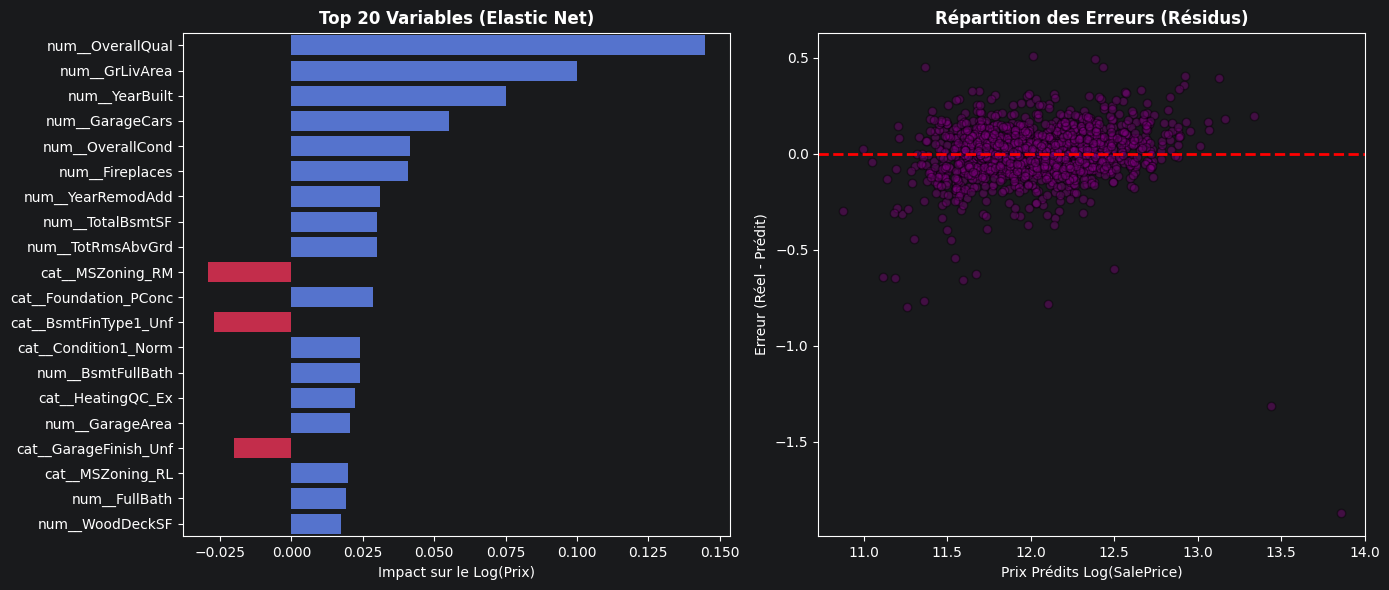

In [5]:
# 4. VISUALISATION DES RÉSULTATS (FEATURE IMPORTANCE & RÉSIDUS)

feature_names = pipeline_elastic.named_steps['preprocessor'].get_feature_names_out()
coefs_df = pd.DataFrame({'Variable': feature_names, 'Coefficient': best_model.coef_})
coefs_df = coefs_df[coefs_df['Coefficient'] != 0]
coefs_df['Abs_Coefficient'] = coefs_df['Coefficient'].abs()
top_20_features = coefs_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

couleurs = top_20_features['Coefficient'].apply(lambda x: 'crimson' if x < 0 else 'royalblue').tolist()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(
    data=top_20_features, x='Coefficient', y='Variable',
    hue='Variable', palette=couleurs, legend=False
)
plt.title("Top 20 Variables (Elastic Net)", fontweight='bold')
plt.xlabel("Impact sur le Log(Prix)")
plt.ylabel("")

# --- 2. ANALYSE DES RÉSIDUS ---
plt.subplot(1, 2, 2)
residus = y_train - y_pred_train
plt.scatter(y_pred_train, residus, alpha=0.4, color='purple', edgecolor='k')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title("Répartition des Erreurs (Résidus)", fontweight='bold')
plt.xlabel("Prix Prédits Log(SalePrice)")
plt.ylabel("Erreur (Réel - Prédit)")

plt.tight_layout()
plt.show()